In [1]:

# Uma rede neural é uma composição de funções:
#   f(x) = fₗ(... f₂(f₁(x)) ...)

# Para otimizar, precisamos de ∂L/∂Wₗ para cada camada l.
# Backprop é a aplicação da regra da cadeia.

# REGRA DA CADEIA (caso escalar):
#   se z = f(y) e y = g(x), então dz/dx = (dz/dy)(dy/dx)
# CASO VETORIAL — Jacobiana:
#   se f: Rⁿ → Rᵐ, a Jacobiana é uma matriz m×n:
#   J_{ij} = ∂fᵢ/∂xⱼ

#   Regra da cadeia: se z = f(g(x)), então
#   dz/dx = (dz/df)(df/dg)(dg/dx) — produto de Jacobianas

# PARA REDES NEURAIS:
# Forward pass: z^(l) = W^(l) a^(l-1) + b^(l)
#               a^(l) = σ(z^(l))

# Backward pass (δ = "delta" = gradiente local):
#   δ^(L) = ∇_a L ⊙ σ'(z^(L))                    <-- camada final
#   δ^(l) = (W^(l+1))ᵀ δ^(l+1) ⊙ σ'(z^(l))       <--- camadas anteriores
#   ∂L/∂W^(l) = δ^(l) (a^(l-1))ᵀ
#   ∂L/∂b^(l) = δ^(l)
#
# ⊙ = produto elemento a elemento (Hadamard)
# O "T" na equação de δ^(l) é a transposta — e ela aparece
# exatamente porque estamos propagando o gradiente de volta
# pelo espaço dual da transformação linear.

In [2]:

import numpy as np
import matplotlib.pyplot as plt

In [3]:


 # PARTE 1 — Jacobiana e regra da cadeia verificadas numericamente
 
def jacobiana_numerica(f, x, eps=1e-5):
    """Jacobiana de f: Rⁿ → Rᵐ via diferença central."""
    fx = f(x)
    m = len(np.atleast_1d(fx))
    n = len(x)
    J = np.zeros((m, n))
    for j in range(n):
        ej = np.zeros(n); ej[j] = 1.
        J[:, j] = (f(x + eps*ej) - f(x - eps*ej)) / (2*eps)
    return J

# função composta: z = f(g(x)) onde g: R² → R³, f: R³ → R²
def g(x):
    return np.array([x[0]*x[1], x[0]**2, np.sin(x[1])])

def f_func(y):
    return np.array([y[0] + y[1], y[1]*y[2]])

x_test = np.array([1.5, 0.8])
y_test = g(x_test)

Jg = jacobiana_numerica(g, x_test)
Jf = jacobiana_numerica(f_func, y_test)
J_composta_regra = Jf @ Jg                            # regra da cadeia
J_composta_num   = jacobiana_numerica(lambda x: f_func(g(x)), x_test)

print("Jacobiana via regra da cadeia:")
print(np.round(J_composta_regra, 6))
print("\nJacobiana numérica direta:")
print(np.round(J_composta_num, 6))
print(f"\nIdênticas? {np.allclose(J_composta_regra, J_composta_num)}")

Jacobiana via regra da cadeia:
[[3.8      1.5     ]
 [2.152068 1.56759 ]]

Jacobiana numérica direta:
[[3.8      1.5     ]
 [2.152068 1.56759 ]]

Idênticas? True


In [4]:
# PARTE 2 — Ativações e suas derivadas
 
def sigmoid(z): return 1. / (1. + np.exp(-z))
def sigmoid_d(z): s = sigmoid(z); return s * (1. - s)

def relu(z): return np.maximum(0., z)
def relu_d(z): return (z > 0.).astype(float)

def tanh_f(z): return np.tanh(z)
def tanh_d(z): return 1. - np.tanh(z)**2

# verificar derivadas numericamente
z_test = np.array([0., 1., -1., 2.])
eps = 1e-5
for nome, ativ, deriv in [('sigmoid', sigmoid, sigmoid_d),
                           ('relu',    relu,    relu_d),
                           ('tanh',    tanh_f,  tanh_d)]:
    d_analitica = deriv(z_test)
    d_numerica  = (ativ(z_test+eps) - ativ(z_test-eps)) / (2*eps)
    ok = np.allclose(d_analitica, d_numerica, atol=1e-6)
    print(f"{nome:8s}: derivada ok? {ok}")

sigmoid : derivada ok? True
relu    : derivada ok? False
tanh    : derivada ok? True


In [5]:
# PARTE 3 — Rede neural do zero com backprop manual
 
class RedeNeural:
    """
    Rede MLP com backprop implementado do zero.
    Arquitetura: [entrada] → [camadas ocultas] → [saída]
    Loss: MSE para regressão.
    """

    def __init__(self, dims, ativacao='relu', seed=42):
        """
        dims: lista de dimensões, ex: [2, 16, 8, 1]
        """
        np.random.seed(seed)
        self.dims = dims
        self.L = len(dims) - 1         # número de camadas com pesos
        self.params = {}

        if ativacao == 'relu':
            self.ativ, self.ativ_d = relu, relu_d
        else:
            self.ativ, self.ativ_d = tanh_f, tanh_d

        # inicialização He (para relu) — escala √(2/n_entrada)
        for l in range(1, len(dims)):
            n_in = dims[l-1]
            n_out = dims[l]
            self.params[f'W{l}'] = np.random.randn(n_out, n_in) * np.sqrt(2./n_in)
            self.params[f'b{l}'] = np.zeros((n_out, 1))

    def forward(self, X):
        """
        X: (n_features, n_amostras)
        Retorna: saída, cache com ativações e pré-ativações
        """
        cache = {'a0': X}
        a = X
        for l in range(1, self.L + 1):
            W = self.params[f'W{l}']
            b = self.params[f'b{l}']
            z = W @ a + b                          # pré-ativação
            # última camada: sem ativação (regressão)
            a = z if l == self.L else self.ativ(z)
            cache[f'z{l}'] = z
            cache[f'a{l}'] = a
        return a, cache

    def loss(self, y_pred, y_true):
        """MSE."""
        n = y_true.shape[1]
        return np.sum((y_pred - y_true)**2) / n

    def backward(self, y_true, cache):
        """
        Backpropagation completo.
        Retorna: dicionário de gradientes para cada W e b.
        """
        grads = {}
        n = y_true.shape[1]
        L = self.L

        # gradiente da loss em relação à saída (MSE)
        # ∂L/∂a^L = 2(a^L - y) / n
        da = 2 * (cache[f'a{L}'] - y_true) / n

        for l in reversed(range(1, L + 1)):
            z = cache[f'z{l}']
            a_prev = cache[f'a{l-1}']
            W = self.params[f'W{l}']

            # ∂L/∂z^l = ∂L/∂a^l ⊙ σ'(z^l)
            # (última camada: sem ativação, σ'=1)
            if l == L:
                dz = da
            else:
                dz = da * self.ativ_d(z)

            # ∂L/∂W^l = dz @ a^{l-1}ᵀ
            grads[f'W{l}'] = dz @ a_prev.T / n
            # ∂L/∂b^l = média de dz sobre amostras
            grads[f'b{l}'] = dz.mean(axis=1, keepdims=True)
            # ∂L/∂a^{l-1} = W^lᵀ @ dz  ← transposta aqui!
            da = W.T @ dz

        return grads

    def verificar_gradientes(self, X, y, eps=1e-5):
        """
        Gradient checking: compara backprop com diferença numérica.
        Retorna erro relativo máximo.
        """
        _, cache = self.forward(X)
        grads = self.backward(y, cache)
        erros = {}

        for key in self.params:
            W = self.params[key]
            dW_bp = grads[key]
            dW_num = np.zeros_like(W)

            for i in range(min(W.shape[0], 3)):   # amostra algumas entradas
                for j in range(min(W.shape[1], 3)):
                    W[i,j] += eps
                    yp, _ = self.forward(X)
                    loss_plus = self.loss(yp, y)
                    W[i,j] -= 2*eps
                    yp, _ = self.forward(X)
                    loss_minus = self.loss(yp, y)
                    W[i,j] += eps
                    dW_num[i,j] = (loss_plus - loss_minus) / (2*eps)

            # erro relativo
            num = np.linalg.norm(dW_bp[:3,:3] - dW_num[:3,:3])
            den = np.linalg.norm(dW_bp[:3,:3]) + np.linalg.norm(dW_num[:3,:3]) + 1e-8
            erros[key] = num / den

        return erros

    def treinar(self, X, y, alpha=0.01, n_iter=1000):
        historico = []
        for i in range(n_iter):
            y_pred, cache = self.forward(X)
            loss_val = self.loss(y_pred, y)
            historico.append(loss_val)
            grads = self.backward(y, cache)
            for key in self.params:
                self.params[key] -= alpha * grads[key]
        return historico

 # PARTE 4 — Treinar em um problema real e verificar gradientes
 
np.random.seed(0)
n_data = 300
X_data = np.random.randn(2, n_data)
# função alvo não-linear: y = sin(x1) + x2²
y_data = np.sin(X_data[0]) + X_data[1]**2
y_data = y_data.reshape(1, -1)

rede = RedeNeural(dims=[2, 32, 16, 1], ativacao='relu')

# gradient checking ANTES de treinar
erros_grad = rede.verificar_gradientes(X_data[:, :10], y_data[:, :10])
print(f"\nGradient checking (erro relativo — deve ser < 1e-5):")
for k, e in erros_grad.items():
    print(f"  {k}: {e:.2e}  {'✓' if e < 1e-4 else '✗'}")

# treinar
hist = rede.treinar(X_data, y_data, alpha=0.005, n_iter=2000)
y_pred_final, _ = rede.forward(X_data)
r2 = 1 - np.sum((y_data - y_pred_final)**2) / np.sum((y_data - y_data.mean())**2)
print(f"\nR² final após 2000 iterações: {r2:.4f}")


Gradient checking (erro relativo — deve ser < 1e-5):
  W1: 8.18e-01  ✗
  b1: 8.18e-01  ✗
  W2: 8.18e-01  ✗
  b2: 8.18e-01  ✗
  W3: 8.18e-01  ✗
  b3: 8.18e-01  ✗

R² final após 2000 iterações: 0.5398


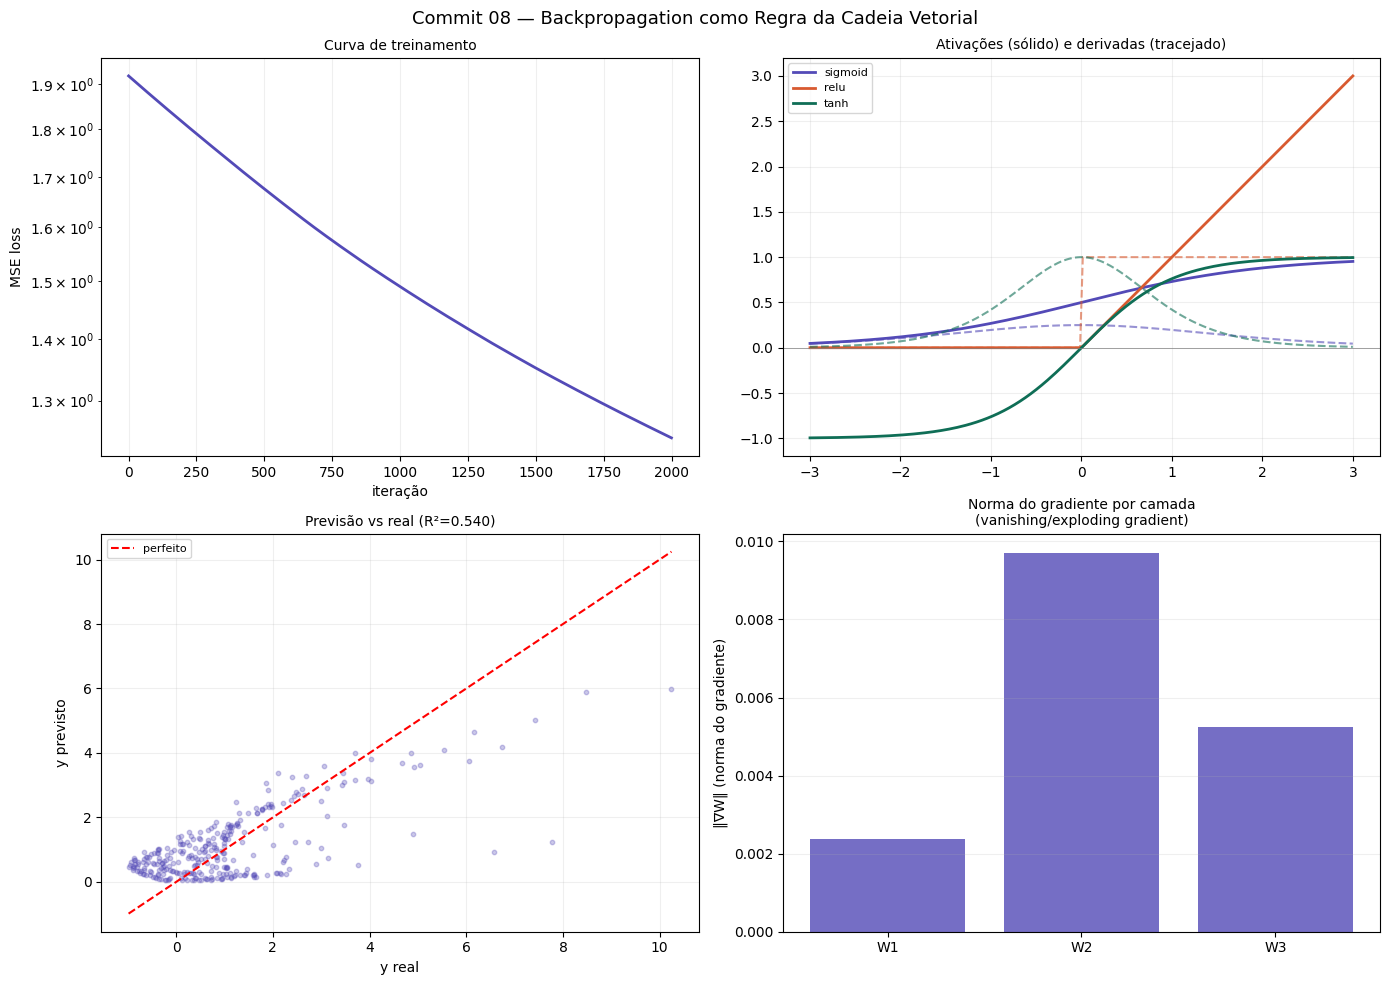

In [6]:



 

 

 # PARTE 5 — VISUALIZAÇÃO
 
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Commit 08 — Backpropagation como Regra da Cadeia Vetorial", fontsize=13)

# Plot 1: curva de loss
ax = axes[0, 0]
ax.plot(hist, color='#534AB7', lw=2)
ax.set_xlabel("iteração"); ax.set_ylabel("MSE loss")
ax.set_title("Curva de treinamento", fontsize=10)
ax.set_yscale('log')
ax.grid(True, alpha=0.2)

# Plot 2: ativações e derivadas
ax2 = axes[0, 1]
z_plot = np.linspace(-3, 3, 200)
for nome, ativ, deriv, cor in [('sigmoid', sigmoid, sigmoid_d, '#534AB7'),
                                 ('relu',    relu,    relu_d,    '#D85A30'),
                                 ('tanh',    tanh_f,  tanh_d,    '#0F6E56')]:
    ax2.plot(z_plot, ativ(z_plot), lw=2, color=cor, label=nome)
    ax2.plot(z_plot, deriv(z_plot), lw=1.5, color=cor, linestyle='--', alpha=0.6)
ax2.set_title("Ativações (sólido) e derivadas (tracejado)", fontsize=10)
ax2.legend(fontsize=8); ax2.grid(True, alpha=0.2)
ax2.axhline(0, color='gray', lw=0.5)

# Plot 3: previsão vs real
ax3 = axes[1, 0]
ax3.scatter(y_data.flatten(), y_pred_final.flatten(),
            alpha=0.3, s=10, color='#534AB7')
lim = [y_data.min(), y_data.max()]
ax3.plot(lim, lim, 'r--', lw=1.5, label='perfeito')
ax3.set_xlabel("y real"); ax3.set_ylabel("y previsto")
ax3.set_title(f"Previsão vs real (R²={r2:.3f})", fontsize=10)
ax3.legend(fontsize=8); ax3.grid(True, alpha=0.2)

# Plot 4: gradientes por camada (norma)
ax4 = axes[1, 1]
_, cache_final = rede.forward(X_data)
grads_final = rede.backward(y_data, cache_final)
camadas = sorted([k for k in grads_final if 'W' in k])
normas = [np.linalg.norm(grads_final[k]) for k in camadas]
ax4.bar(range(len(camadas)), normas, color='#534AB7', alpha=0.8)
ax4.set_xticks(range(len(camadas)))
ax4.set_xticklabels(camadas)
ax4.set_ylabel("‖∇W‖ (norma do gradiente)")
ax4.set_title("Norma do gradiente por camada\n(vanishing/exploding gradient)", fontsize=10)
ax4.grid(True, alpha=0.2, axis='y')
# normas muito pequenas nas primeiras camadas = vanishing gradient

plt.tight_layout()
plt.savefig('../assets/08_backpropagation.png', dpi=150, bbox_inches='tight')
plt.show()

